In [14]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("./plots.mplstyle")
import os

def mean_sem_for_run(run_path, prefix, tag):
    """Auto-detect how many repeats exist for prefix_tag in run_path,
    load them all, and return (freqs_hz, x_mean, x_sem, n_repeats).
    Skips any repeat whose length doesn't match the expected full-sweep
    length (from freqs_hz) -- a partial repeat (interlock trip or an
    overload give-up) is saved to disk by cmd_sweep_average() but should
    be excluded from averaging, same convention as the saved _avg_*.npy
    files use."""
    freqs_hz = np.load(f"{run_path}/{prefix}_{tag}_repeat0_freqs_hz.npy")
    expected_len = len(freqs_hz)
    reps = []
    r = 0
    n_skipped = 0
    while os.path.exists(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy"):
        x_rep = np.load(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy")
        if len(x_rep) == expected_len:
            reps.append(x_rep)
        else:
            n_skipped += 1
        r += 1
    if n_skipped:
        print(f"  ({prefix}_{tag}: skipped {n_skipped} partial repeat(s))")
    x_reps = np.stack(reps)
    x_mean = x_reps.mean(axis=0)
    n = len(reps)
    x_sem = x_reps.std(axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(x_mean)
    return freqs_hz, x_mean, x_sem, n




In [15]:
RUNS_89 = [
    (r"D:\cw_odmr_lock_in\powerstudy8", "powerstudy8"),
    
]
POWER_TAGS_89 = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
    "-25 dBm": "pm25dBm",
}

power_stats_89 = {}
for label, tag in POWER_TAGS_89.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_89:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_89[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy8 contributes 152 points, 25 repeats
-5 dBm: powerstudy8 contributes 152 points, 25 repeats
-10 dBm: powerstudy8 contributes 152 points, 25 repeats
-15 dBm: powerstudy8 contributes 152 points, 25 repeats
-20 dBm: powerstudy8 contributes 152 points, 25 repeats
-25 dBm: powerstudy8 contributes 152 points, 25 repeats


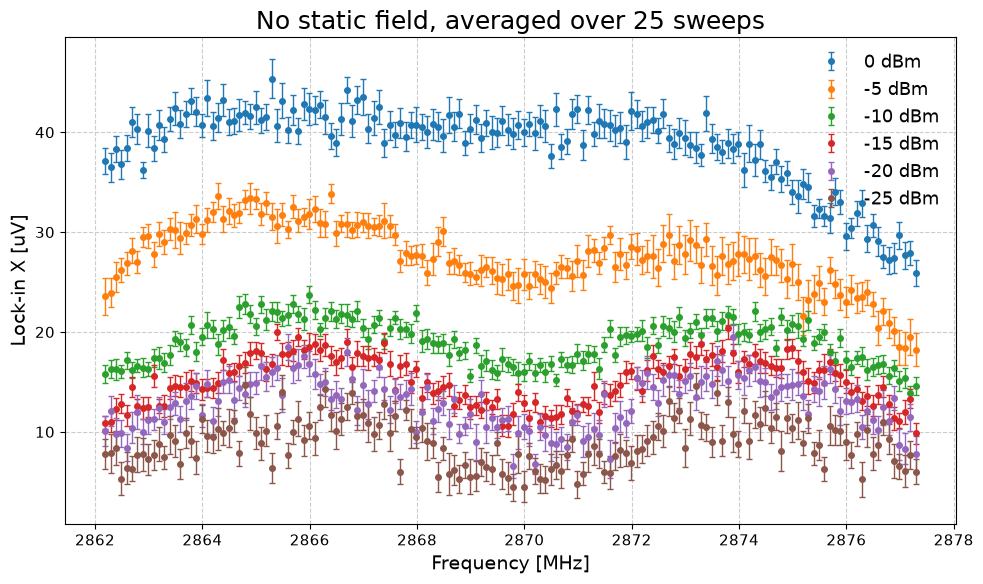

In [31]:
fig, ax = plt.subplots(figsize=(10,6))

for label, d in power_stats_89.items():
    ax.errorbar(d["freqs_ghz"] * 1e3, d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Lock-in X [uV]")
ax.set_title("No static field, averaged over 25 sweeps")

ax.legend()
plt.tight_layout()
plt.savefig("./figs/averaged-25.png", dpi=300)

plt.show()

In [17]:
RUNS_POWERSCAN = [
    (r"D:\cw_odmr_lock_in\powerscan1", "powerscan1"),
    (r"D:\cw_odmr_lock_in\powerscan2", "powerscan2"),
    (r"D:\cw_odmr_lock_in\powerscan3", "powerscan3"),
    (r"D:\cw_odmr_lock_in\powerscan4", "powerscan4"),
    (r"D:\cw_odmr_lock_in\powerscan5", "powerscan5"),
    (r"D:\cw_odmr_lock_in\powerscan6", "powerscan6"),
    (r"D:\cw_odmr_lock_in\powerscan7", "powerscan7"),
    (r"D:\cw_odmr_lock_in\powerscan8", "powerscan8"),
]
POWER_TAGS_POWERSCAN = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
}

power_stats_powerscan = {}
for label, tag in POWER_TAGS_POWERSCAN.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_POWERSCAN:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_powerscan[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerscan1 contributes 136 points, 1 repeats
0 dBm: powerscan2 contributes 121 points, 1 repeats
0 dBm: powerscan3 contributes 137 points, 1 repeats
0 dBm: powerscan4 contributes 51 points, 1 repeats
0 dBm: powerscan5 contributes 51 points, 1 repeats
0 dBm: powerscan6 contributes 61 points, 1 repeats
0 dBm: powerscan7 contributes 41 points, 1 repeats
0 dBm: powerscan8 contributes 31 points, 1 repeats
-5 dBm: powerscan1 contributes 136 points, 1 repeats
-5 dBm: powerscan2 contributes 121 points, 1 repeats
-5 dBm: powerscan3 contributes 137 points, 1 repeats
-5 dBm: powerscan4 contributes 51 points, 1 repeats
-5 dBm: powerscan5 contributes 51 points, 1 repeats
-5 dBm: powerscan6 contributes 61 points, 1 repeats
-5 dBm: powerscan7 contributes 41 points, 1 repeats
-5 dBm: powerscan8 contributes 31 points, 1 repeats
-10 dBm: powerscan1 contributes 136 points, 1 repeats
-10 dBm: powerscan2 contributes 121 points, 1 repeats
-10 dBm: powerscan3 contributes 137 points, 1 repeats
-10 dBm:

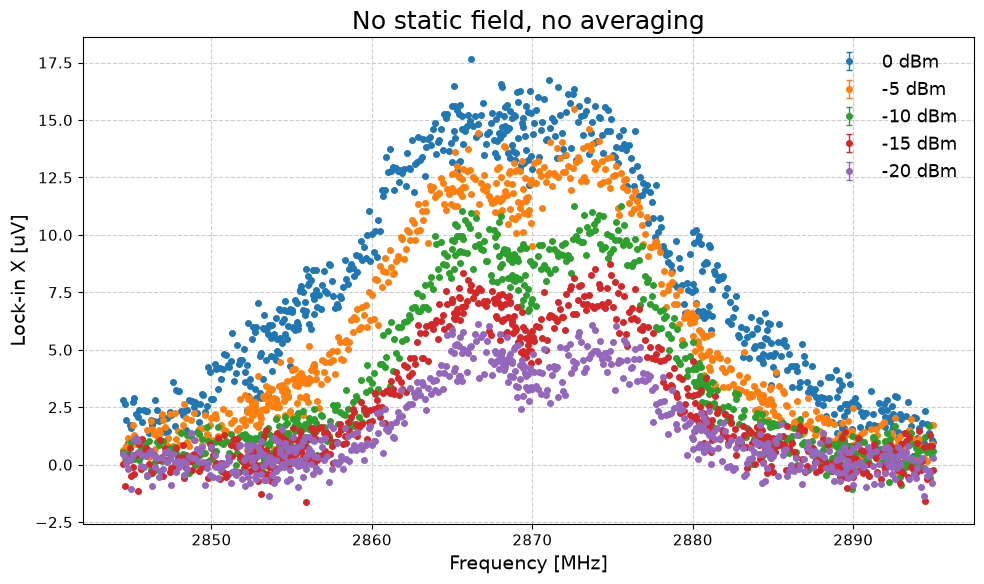

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_powerscan.items():
    ax.errorbar(d["freqs_ghz"] * 1e3, d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Lock-in X [uV]")
ax.set_title("No static field, no averaging")

ax.legend()
plt.tight_layout()
plt.savefig("./figs/no-averaging.png", dpi=300)

plt.show()